# CLOUDY simulation report
## Israt Sultana Eithu

Tasks:

The following tasks were assigned for this CLOUDY simulation:

1. Plot the spectrum of planetary nebulae (PNe) for different abundances and discuss the differences observed in the spectra.

2. Plot the temperature structure of the planetary nebula from the overview (`.ovr`) file, i.e. distance from the center (first column) versus gas temperature (second column).

3. Perform a BLR (Broad Line Region) cloud simulation grid for different ionization fluxes and gas densities (following Section 6.4 of the CLOUDY Quick Start guide), and study how the Hα/Hβ ratio varies across the parameter plane.

4. CPU time

# 1. PNe Spectrum Comparison

### Planetary Nebula Abundances

```text
blackbody T=1e5 K
luminosity total 38
radius 18
hden 5
sphere
abundances planetary nebula
iterate
print last iteration
save overview "pn.ovr" last
save continuum "pn.con" units microns last
```

### Solar Abundances

```text
blackbody T=1e5 K
luminosity total 38
radius 18
hden 5
sphere
abundances solar
iterate
print last iteration
save overview "solar.ovr" last
save continuum "solar.con" units microns last
```

### HII Region Abundances

```text
blackbody 1e5 K
luminosity total solar 38
hden 5
radius 18
sphere
abundances HII region
iterate to convergence
print last iteration
save overview "hii.ovr" last
save continuum "hii.con" units microns last
```

### ISM Abundances

```text
blackbody 1e5 K
luminosity total 38
radius 18
hden 5
sphere
abundances ISM
iterate
print last iteration
save overview "ism.ovr" last
save continuum "ism.con" units microns last
```

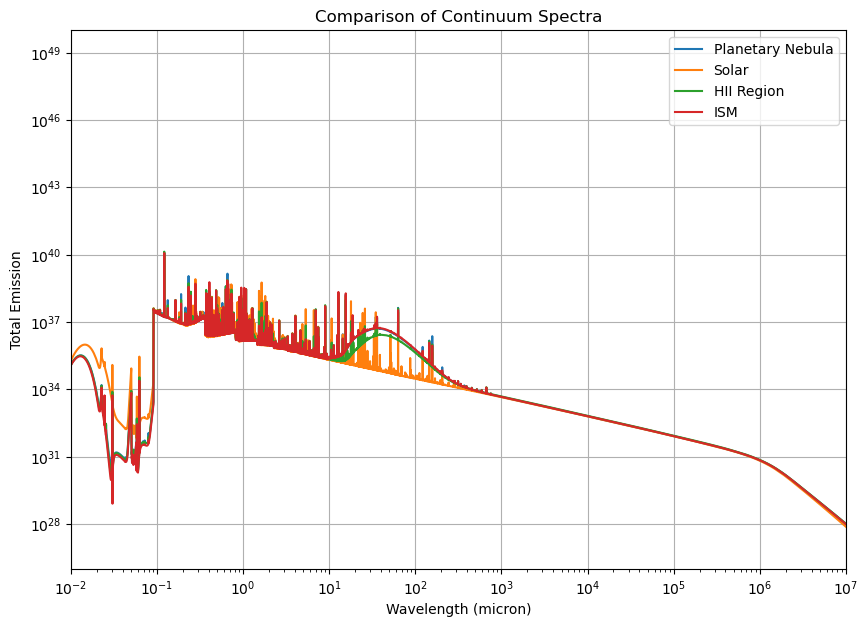

In [82]:
import matplotlib.pyplot as plt

# ---------- Function ----------
def load_con_file(filename):

    wave = []
    flux = []

    with open(filename) as f:

        for line in f:

            if line.startswith("#"):
                continue

            cols = line.split()

            try:
                wave.append(float(cols[0]))
                flux.append(float(cols[6]))

            except:
                pass

    return wave, flux


# ---------- Load Files ----------
pn_wave, pn_flux = load_con_file("/home/israt/c25.00/tsuite/cloudy_hw/pn.con")

solar_wave, solar_flux = load_con_file("/home/israt/c25.00/tsuite/cloudy_hw/solar.con")

hii_wave, hii_flux = load_con_file("/home/israt/c25.00/tsuite/cloudy_hw/hii.con")

ism_wave, ism_flux = load_con_file("/home/israt/c25.00/tsuite/cloudy_hw/ism.con")


# ---------- Plot ----------
plt.figure(figsize=(10,7))

plt.loglog(pn_wave, pn_flux, label="Planetary Nebula")

plt.loglog(solar_wave, solar_flux, label="Solar")

plt.loglog(hii_wave, hii_flux, label="HII Region")

plt.loglog(ism_wave, ism_flux, label="ISM")


# ---------- Axis ----------
plt.xlim(1e-2, 1e7)

plt.ylim(1e26, 1e50)

plt.xlabel("Wavelength (micron)")

plt.ylabel("Total Emission")

plt.title("Comparison of Continuum Spectra")


# ---------- Style ----------
plt.grid(True)

plt.legend()


# ---------- Save ----------
plt.savefig("all_spectra_comparison.png",
            dpi=300,
            bbox_inches='tight')


# ---------- Show ----------
plt.show()

### Discussion

The spectra are different because the chemical abundances affect the ionization balance, cooling processes, and emission mechanisms of the gas.

Different elements produce different emission lines and continuum strengths. The HII region shows stronger thermal emission, while the planetary nebula and ISM cases contain stronger line features due to ionized gas and recombination processes.

The abundance composition changes the radiative cooling efficiency, which modifies the overall spectral shape and intensity.

# 2. Temperature Structure of the PNe

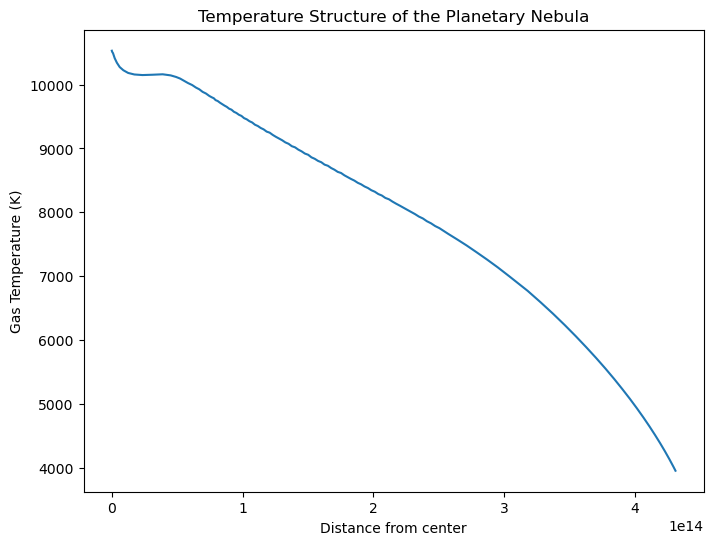

In [83]:


ovr = pd.read_csv(
    "/home/israt/c25.00/tsuite/cloudy_hw/pn.ovr",
    sep=r"\s+",
    comment="#",
    header=None,
    engine="python"
)

plt.figure(figsize=(8,6))

plt.plot(
    ovr[0],
    ovr[1]
)

plt.xlabel("Distance from center")
plt.ylabel("Gas Temperature (K)")

plt.title("Temperature Structure of the Planetary Nebula")
plt.savefig("temp_of_pne.png", dpi=300, bbox_inches='tight')
plt.show()

## 3. BLR Cloud Simulation Grid

### BLR Input File

```text
table power law
phi(H) 18.5 vary
grid from 18 to 24 in 1.0 dex steps
hden 10 vary
grid from 8 to 14 in 1.0 dex steps
stop column density 22
iterate
save line list "blr.line" "LineList.dat" no clobber
save grid "blr.grd" no clobber
```
### Processing the BLR Output

The generated `blr.line` file contained multiple iterations and additional text entries. Therefore, a Bash script was used to extract only the iteration 2 results and calculate the Hα/Hβ ratio for each grid point.

The script also mapped the luminosity and density grid values and produced a clean data file (`hahb_final.dat`) containing:

- Ionizing luminosity
- Hydrogen density
- Hα/Hβ ratio

```bash
#!/bin/bash

grep "iteration 2" blr.line | awk '
BEGIN { i=0; j=0 }
{
    phi = 18 + (i * 0.5)
    hden = 8 + (j * 0.5)

    if ($3 > 0) {
        ratio = $2 / $3
        print phi, hden, ratio
    }

    i++
    if (i > 12) { i=0; j++ }
}' > hahb_final.dat

echo "Processing complete. Check hahb_final.dat"
```

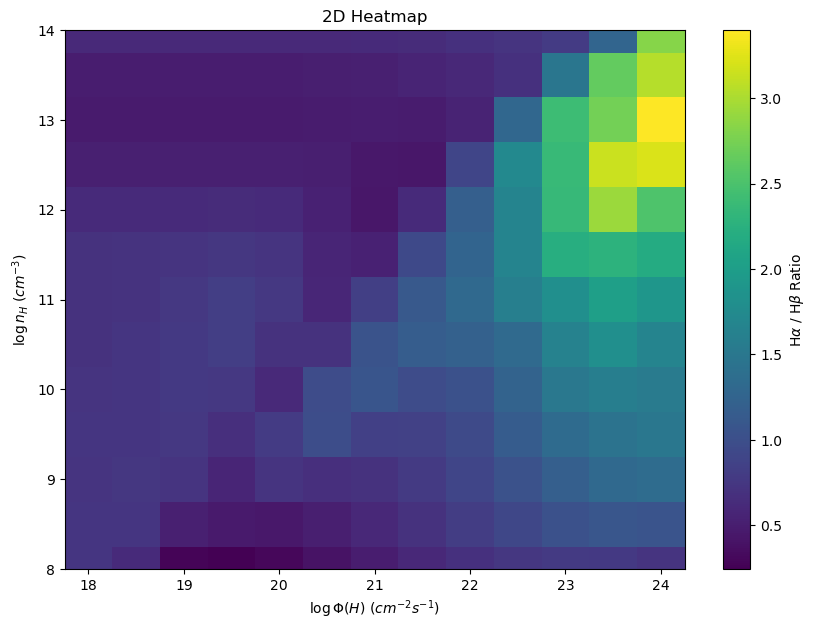

In [87]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 1. Load the cleaned data
data = pd.read_csv('/home/israt/c25.00/tsuite/cloudy_hw/hahb_final.dat', sep='\s+', names=['logPhi', 'logH', 'ratio'])

# 2. Reshape data into a grid format
pivot_table = data.pivot(index='logH', columns='logPhi', values='ratio')

# --- PLOT 1: 2D Heatmap  ---
plt.figure(figsize=(10, 7))

plt.pcolormesh(pivot_table.columns, pivot_table.index, pivot_table.values, 
               cmap='viridis', shading='auto')

plt.colorbar(label=r'H$\alpha$ / H$\beta$ Ratio')

# Setting labels 
plt.xlabel(r'$\log \Phi(H)$ ($cm^{-2} s^{-1}$)')
plt.ylabel(r'$\log n_H$ ($cm^{-3}$)')
plt.title('2D Heatmap')

# Fix the axis range 
plt.gca().set_ylim(bottom=data['logH'].min(), top=data['logH'].max())
plt.savefig("2d_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()



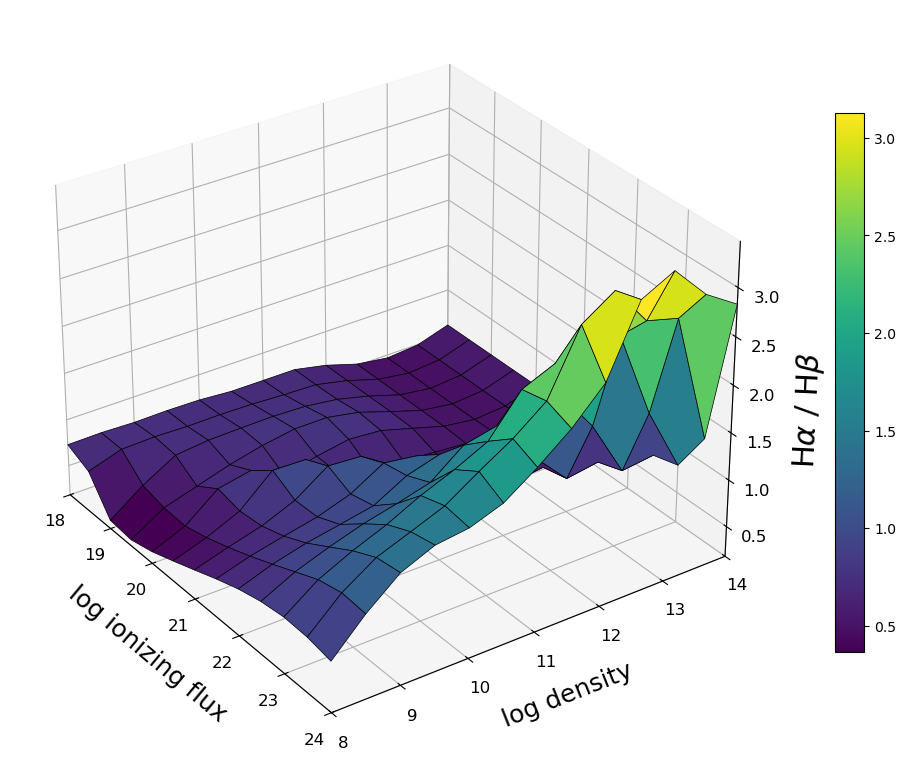

In [85]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Load data
data = pd.read_csv(
    'hahb_final.dat',
    sep=r'\s+',
    names=['logPhi', 'logH', 'ratio']
)

# Create grid
pivot = data.pivot(
    index='logH',
    columns='logPhi',
    values='ratio'
)

X, Y = np.meshgrid(pivot.columns, pivot.index)
Z = pivot.values

# Figure
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Surface
surf = ax.plot_surface(
    X,
    Y,
    Z,
    cmap='viridis',
    edgecolor='k',
    linewidth=0.5,
    antialiased=True,
    shade=True
)


ax.view_init(elev=30, azim=-35)

# Labels
ax.set_xlabel('log ionizing flux', fontsize=18, labelpad=12)
ax.set_ylabel('log density', fontsize=18, labelpad=12)
ax.set_zlabel(r'H$\alpha$ / H$\beta$', fontsize=22, labelpad=10)

# Axis ranges
ax.set_xlim(18,24)
ax.set_ylim(8,14)

# Tick sizes
ax.tick_params(axis='both', labelsize=12)

# Colorbar
cbar = fig.colorbar(
    surf,
    shrink=0.7,
    aspect=18,
    pad=0.08
)

# Layout
plt.tight_layout()
plt.savefig("variation3d.png", dpi=300, bbox_inches='tight')

plt.show()

### Discussion

The Hα/Hβ ratio varies significantly across the density and ionizing flux parameter space.

At low densities and moderate ionizing flux, the ratio becomes larger due to recombination effects and optical depth changes.

The behavior is consistent with the trends shown in the CLOUDY Quick Start guide.

## 4. Computational Performance

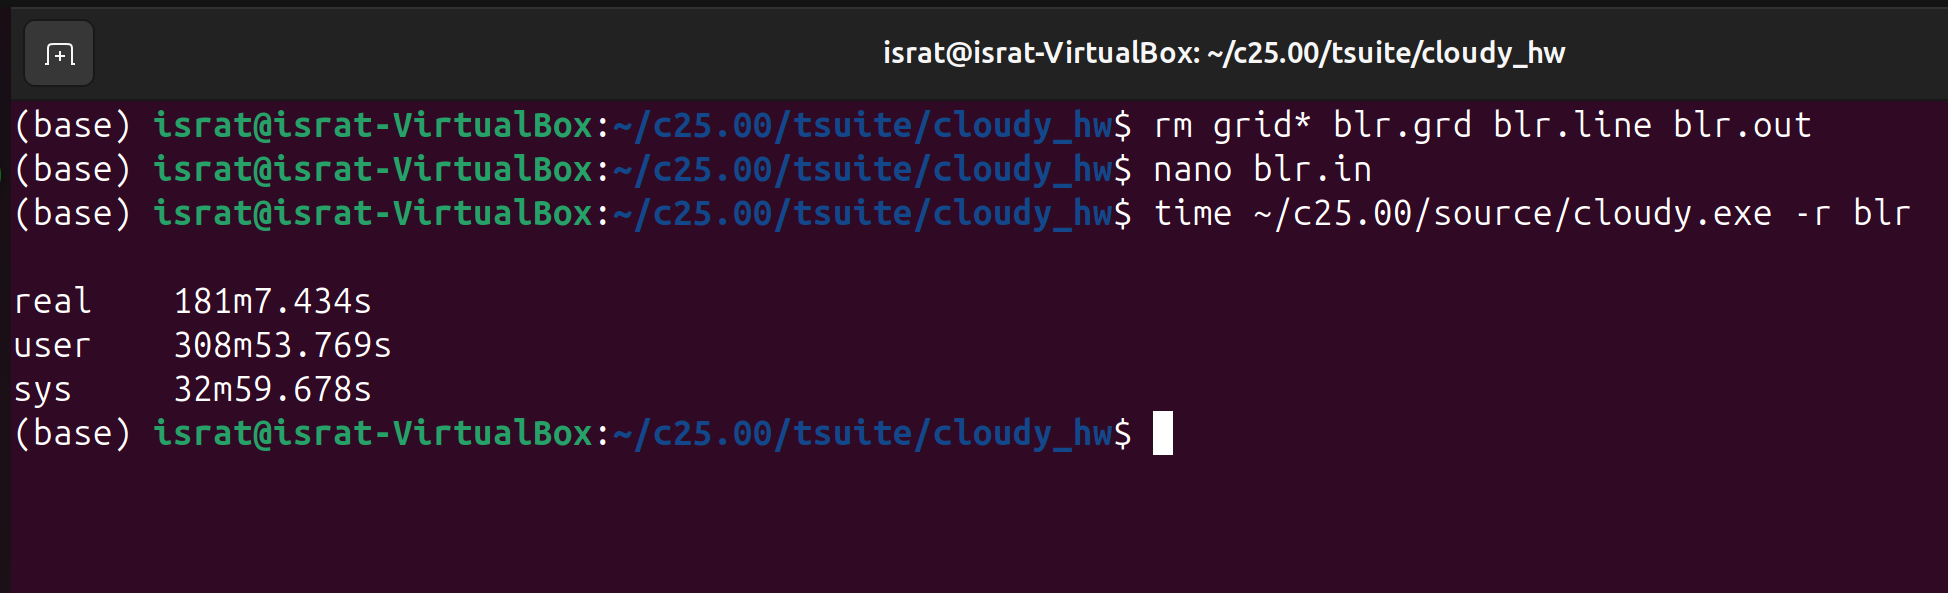

In [86]:
from IPython.display import Image, display

display(Image(filename='/home/israt/c25.00/tsuite/cloudy_hw/time.png'))

### Discussion

The BLR grid simulation required significantly more computational time compared to the single-cloud simulations because the code had to calculate many combinations of density and ionizing flux parameters over the entire grid.

Initially, the simulation did not run properly when the VirtualBox processor setting was configured with 8 CPUs. After reducing the allocated processors to 2 CPUs, the simulation completed successfully, although the runtime became much longer.

The measured execution times were approximately:

- Real time: 181 minutes
- User CPU time: 308 minutes
- System time: 32 minutes
